# House Price Prediction

In this project, I will build a machine learning model to predict house prices.
The dataset is based on apartment listings from Azerbaijan, mainly Baku.

The main goal is to practice a full regression workflow:
- loading a real dataset
- exploring the data
- preprocessing features
- training models
- evaluating model performance

## 1. Import Libraries

Import libraries that will be used for data analysis, visualization, preprocessing, and machine learning.

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

I saved the Azerbaijan apartment price dataset inside the `data` folder. 
It includes information such as location, number of rooms, apartment area, floor, building type, repair status, bill of sale, mortgage availability, and price.
The file is loaded with pandas from a local CSV file.

In [2]:
df = pd.read_csv("data/BakuApartmentData.csv", index_col=0)
df.head()

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage
0,177000,Həzi Aslanov m.,4,117.0,12/16,1,1,1,1
1,190000,Şah İsmayıl Xətai m.,2,80.0,5/16,1,1,1,1
2,430000,Elmlər Akademiyası m.,4,170.0,3/17,1,1,1,1
3,465000,Elmlər Akademiyası m.,4,186.0,9/15,1,1,1,1
4,265500,28 May m.,3,96.0,8/16,1,1,1,1


The first unnamed column in the CSV is only an old index, so I used `index_col=0` while reading the file.

The target column is `price`. This is the value that the model will try to predict later.

## 3. Basic Dataset Information

Now I check num of rows and columns in the dataset.

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 458075
Columns: 9


In [4]:
df.columns

Index(['price', 'location', 'rooms', 'square', 'floor', 'new_building',
       'has_repair', 'has_bill_of_sale', 'has_mortgage'],
      dtype='str')

I will check the data types. This is important because numeric and categorical columns will need different preprocessing steps later.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 458075 entries, 0 to 458074
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   price             458075 non-null  int64  
 1   location          458075 non-null  str    
 2   rooms             458075 non-null  int64  
 3   square            458075 non-null  float64
 4   floor             458075 non-null  str    
 5   new_building      458075 non-null  int64  
 6   has_repair        458075 non-null  int64  
 7   has_bill_of_sale  458075 non-null  int64  
 8   has_mortgage      458075 non-null  int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 31.5 MB


## 4. Summary Statistics

Here I look at simple summary statistics for numeric columns, such as mean, minimum, maximum, and standard deviation.

In [6]:
df.describe()

,price,rooms,square,new_building,has_repair,has_bill_of_sale,has_mortgage
count,4.580750e+05,458075.000000,458075.000000,458075.000000,458075.000000,458075.000000,458075.000000
mean,2.418705e+05,2.829873,110.213341,0.359572,0.423151,0.518509,0.461505
std,1.845307e+05,0.896957,59.326530,0.479876,0.494060,0.499658,0.498516
min,9.600000e+03,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000
25%,1.450000e+05,2.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000e+05,3.000000,100.000000,0.000000,0.000000,1.000000,0.000000
75%,2.880000e+05,3.000000,135.000000,1.000000,1.000000,1.000000,1.000000
max,8.075000e+06,20.000000,1600.000000,1.000000,1.000000,1.000000,1.000000


## 5. Missing Values

Finally, I check missing values. This will help me decide what preprocessing steps are needed in the next parts of the project.

If a column has missing values, I will later decide whether to fill them, remove rows, or handle them with a preprocessing pipeline.

In [7]:
missing_values = df.isnull().sum()

missing_values

price               0
location            0
rooms               0
square              0
floor               0
new_building        0
has_repair          0
has_bill_of_sale    0
has_mortgage        0
dtype: int64

In [8]:
missing_values.sort_values(ascending=False)

price               0
location            0
rooms               0
square              0
floor               0
new_building        0
has_repair          0
has_bill_of_sale    0
has_mortgage        0
dtype: int64

This check shows which columns have missing data and how many missing values each column contains.
In the preprocessing step, I will handle missing values before training the models.

## 6. Exploratory Data Analysis

The main goal is to understand apartment prices in Baku and see how price changes by location, number of rooms, and apartment size.

### Price Distribution

First, I look at the distribution of apartment prices. This helps me understand the general price range and whether there are very expensive apartments in the dataset.

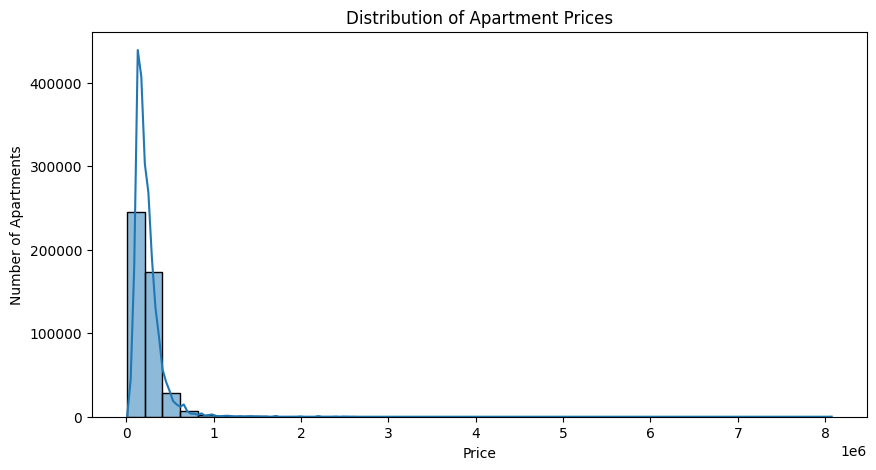

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=40, kde=True)

plt.title("Distribution of Apartment Prices")
plt.xlabel("Price")
plt.ylabel("Number of Apartments")
plt.show()

Most apartment prices are concentrated in the lower price range. The distribution is strongly right-skewed, which means there are a few very expensive apartments compared to the majority of listings.

Because of these high-price listings, I should check possible outliers later before training the models.

In [10]:
df.sort_values("price", ascending=False).head(10)

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage
167347,8075000,İçəri Şəhər m.,4,315.0,6/19,0,1,1,1
304149,8075000,İçəri Şəhər m.,4,315.0,6/19,0,0,1,1
21052,8075000,İçəri Şəhər m.,4,315.0,6/19,1,1,0,0
232488,8075000,İçəri Şəhər m.,4,315.0,6/19,0,1,0,0
11789,8075000,İçəri Şəhər m.,4,315.0,6/19,1,1,0,1
2636,8075000,İçəri Şəhər m.,4,315.0,6/19,1,1,1,1
382264,8075000,İçəri Şəhər m.,4,315.0,6/19,0,0,0,0
265175,8075000,İçəri Şəhər m.,4,315.0,6/19,0,1,1,0
59669,8075000,İçəri Şəhər m.,4,315.0,6/19,1,0,1,1
343206,8075000,İçəri Şəhər m.,4,315.0,6/19,0,0,0,1


This table helps see possible luxury apartments or outliers. Very expensive apartments are not always errors, but they can strongly affect model training later.

The most expensive listings show repeated apartments with the same price, location, room count, area, and floor. However, some binary columns are different, such as repair status, mortgage, or bill of sale.

This may indicate duplicated or noisy scraped data. I will keep this in mind and handle duplicate rows during preprocessing.

In [20]:
full_duplicates = df.duplicated().sum()
main_duplicates = df.duplicated(
    subset=["price", "location", "rooms", "square", "floor"]
).sum()

print("Full duplicate rows:", full_duplicates)
print("Duplicate rows by main apartment columns:", main_duplicates)

np.int64(425143)

In [ ]:
The dataset contains many duplicate rows. There are 74,506 fully duplicated rows, and 425,143 rows are repeated when checking the main apartment description columns: price, location, rooms, square, and floor.

This suggests that the scraped dataset contains many repeated listings. I will not remove them during EDA yet, but duplicate handling will be an important preprocessing step before model training.

### Cheapest Apartments

I also check the cheapest apartments because very low prices may be unusual or may represent small apartments, old buildings, or listings with missing details.

In [11]:
df.sort_values("price").head(10)  # ascending default is True

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage
418692,9600,Həzi Aslanov m.,1,26.0,1/9,0,0,0,0
457763,9600,Həzi Aslanov m.,1,26.0,1/9,0,0,1,0
376794,17000,Sahil m.,1,12.0,1/2,0,0,0,1
337737,17000,Sahil m.,1,12.0,1/2,0,0,1,1
454923,17000,Sahil m.,1,12.0,1/2,0,0,1,0
298763,17000,Sahil m.,1,12.0,1/2,0,1,1,0
415852,17000,Sahil m.,1,12.0,1/2,0,0,0,0
358194,23000,Masazır q.,1,24.0,1/5,0,0,0,1
397252,23000,Masazır q.,1,24.0,1/5,0,0,0,0
124389,23000,Masazır q.,1,24.0,1/5,1,0,0,0


Checking the cheapest listings is useful because extremely low values can sometimes be data entry mistakes. I will not remove anything yet, but I will keep these values in mind for preprocessing.

### Price by Number of Rooms

Now I compare apartment prices by number of rooms. In general, apartments with more rooms should have higher prices.

In [12]:
room_price = df.groupby("rooms")["price"].mean().sort_index()
room_price

rooms
1     1.081448e+05
2     1.544479e+05
3     2.409559e+05
4     3.865050e+05
5     5.119374e+05
6     8.087682e+05
7     9.830281e+05
8     1.291083e+06
9     1.524709e+06
10    2.137969e+06
11    1.696000e+06
12    2.600000e+05
13    4.000000e+06
14    1.236364e+06
15    2.773056e+06
20    2.300000e+06
Name: price, dtype: float64

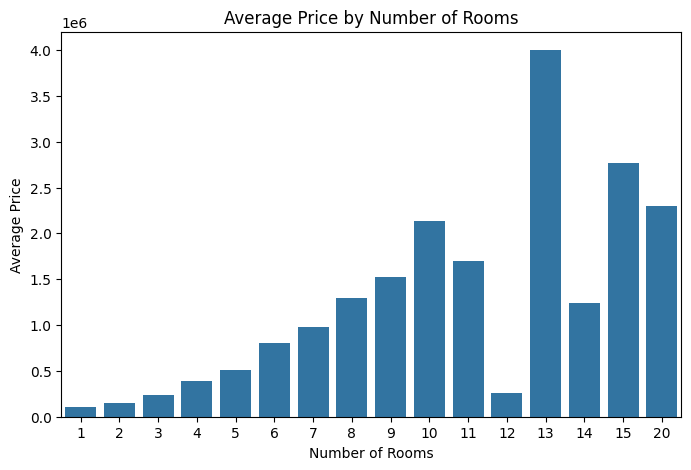

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x=room_price.index, y=room_price.values)

plt.title("Average Price by Number of Rooms")
plt.xlabel("Number of Rooms")
plt.ylabel("Average Price")
plt.show()

This chart shows the average apartment price for each room count. It gives a simple first look at how apartment size category relates to price.

### Price per Square Meter

Apartment price alone is not always enough. A large apartment can be expensive mainly because it has more space. That is why I will create a simple `price_per_sqm` column.

In [14]:
df["price_per_sqm"] = df["price"] / df["square"]

df[["price", "square", "price_per_sqm"]].head()

,price,square,price_per_sqm
0,177000,117.0,1512.820513
1,190000,80.0,2375.000000
2,430000,170.0,2529.411765
3,465000,186.0,2500.000000
4,265500,96.0,2765.625000


The 'price_per_sqm' column helps compare apartments with different sizes more fairly.

In [15]:
df["price_per_sqm"].describe()

count    458075.000000
mean       2173.670658
std         668.031518
min         269.541779
25%        1790.123457
50%        2098.159509
75%        2490.566038
max       25634.920635
Name: price_per_sqm, dtype: float64

### Most Expensive Locations by Average Price

Now I check which locations have the highest average apartment prices. To make the result more reliable, I only include locations with at least 20 listings.

In [16]:
location_stats = (
    df.groupby("location")
    .agg(
        average_price=("price", "mean"),
        average_price_per_sqm=("price_per_sqm", "mean"),
        apartment_count=("price", "count")
    )
    .sort_values("average_price", ascending=False)
)

popular_locations = location_stats[location_stats["apartment_count"] >= 20]

popular_locations.head(10)

,average_price,average_price_per_sqm,apartment_count
location,,,
Sahil m.,547033.222812,3534.006676,3016
İçəri Şəhər m.,485697.856421,3272.687673,4158
Ağ şəhər q.,422428.898973,2922.987830,4771
Nardaran q.,370070.802469,3679.705609,810
Elmlər Akademiyası m.,353991.232298,2547.852582,19574
28 May m.,351253.749635,2488.953943,19196
Şıxov q.,350484.873950,2179.506591,119
Səbail r.,347969.174579,2504.028892,2612
Nizami m.,347473.716032,2512.904010,16118


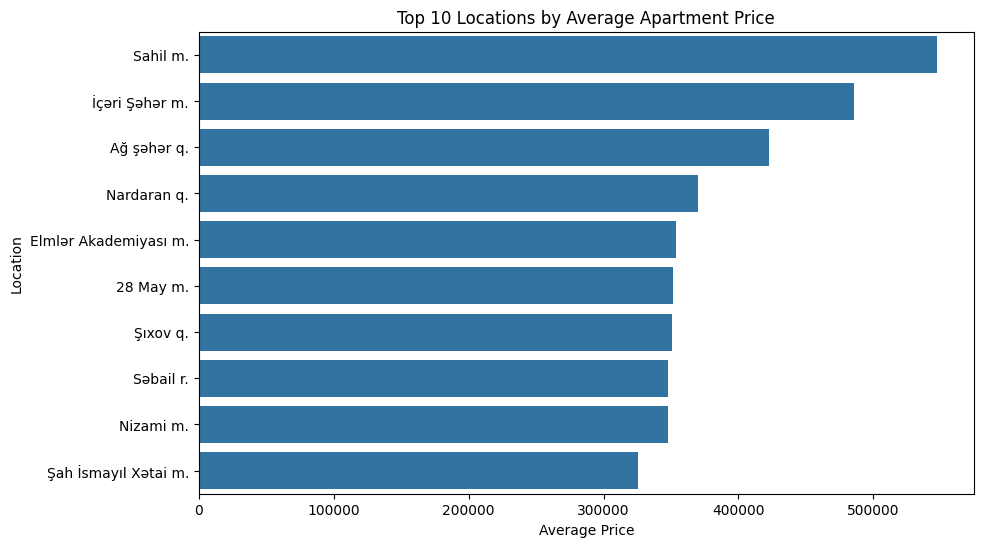

In [17]:
top_locations = popular_locations.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_locations,
    x="average_price",
    y=top_locations.index
)

plt.title("Top 10 Locations by Average Apartment Price")
plt.xlabel("Average Price")
plt.ylabel("Location")
plt.show()

This chart gives a first view of where apartments are more expensive in Baku. I used locations with at least 20 listings because locations with only a few listings can give misleading averages.

### Apartment Area vs Price

Finally, I check the relationship between apartment area and price. Usually, larger apartments should cost more.

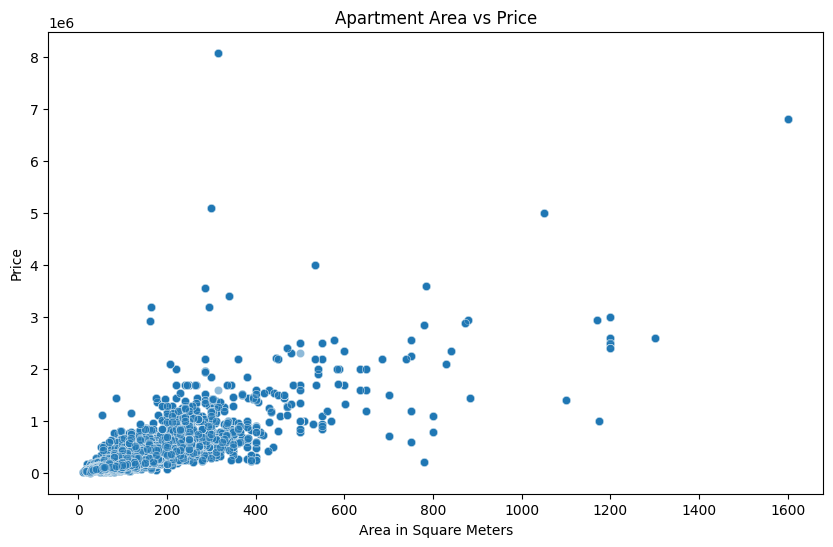

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="square", y="price", alpha=0.5)

plt.title("Apartment Area vs Price")
plt.xlabel("Area in Square Meters")
plt.ylabel("Price")
plt.show()

The scatter plot shows the relationship between apartment area and price. If the points generally move upward, it means larger apartments usually have higher prices.

## 7. EDA Notes

From the first EDA step, I can see that apartment prices are not evenly distributed. Some apartments are much more expensive than the majority of listings.

The number of rooms, apartment area, and location all seem important for predicting price. The new `price_per_sqm` column is also useful for comparing locations more fairly.